In [1]:
import matplotlib.pyplot as plt
import logging
import re
from PCAfold import normalized_variance_derivative, cost_function_normalized_variance_derivative
import numpy as np
import matplotlib.cm as cm
import matplotlib.ticker as ticker
logging.disable(logging.CRITICAL)

In [2]:
import os

#add the root directory
os.chdir('../')

## Visualize individual costs

In [20]:
path_variance = "data-files/costs/"

name_PCA = "variance_PCA_pareto_major-bw_-6_2_100-dataset_autoignition.npy"
name_f_PV_1b = "variance_Tr1bUpdatedData_RMSprop_250_major_s3-bw_-6_2_100-dataset_CFLF-2022.npy"
name_2PV_1f = "variance_Tr1e2PVparetoNoSL_RMSprop_250_major_s3-bw_-6_2_100-dataset_CFLF-2022.npy"
#name_optimized = "variance_Tr0D-2s_s2-bw_-6_2_100-dataset_autoignition.npy"

#"variance_Tr1f2PVpareto300kBis_RMSprop_250_major_s1-bw_-6_2_100-dataset_CFLF-2022.npy"

penalty_function = 'log-sigma-over-peak'
power = 4
vertical_shift = 1

variance_PCA = np.load(f"{path_variance}{name_PCA}", allow_pickle=True).item()
variance_f_PV_1b = np.load(f"{path_variance}{name_f_PV_1b}", allow_pickle=True).item()
variance_2PV_1f = np.load(f"{path_variance}{name_2PV_1f}", allow_pickle=True).item()
#variance_optimized = np.load(f"{path_variance}{name_optimized}", allow_pickle=True).item()

(derivative_PCA, bandwidth_values_PCA, max_PCA) = normalized_variance_derivative(variance_PCA)
(derivative_f_PV_1b, bandwidth_values_f_PV_1b, max_derivative_f_PV_1b) = normalized_variance_derivative(variance_f_PV_1b)
(derivative_2PV_1f, bandwidth_values_2PV_1f, max_derivative_2PV_1f) = normalized_variance_derivative(variance_2PV_1f)
#(derivative_optimized, bandwidth_values_optimized, max_derivative_optimized) = normalized_variance_derivative(variance_optimized)

keys = ['H2O2', 'H2O', 'H2', 'HO2', 'N2O', 'NO2', 'NO', 'O2', 'OH', 'T', 'PV1']

costsPCA = cost_function_normalized_variance_derivative(variance_PCA,
                                                            penalty_function=penalty_function,
                                                            power=power,
                                                            vertical_shift=vertical_shift,
                                                            norm=None)
costsf_PV_1b = cost_function_normalized_variance_derivative(variance_f_PV_1b,
                                                            penalty_function=penalty_function,
                                                            power=power,
                                                            vertical_shift=vertical_shift,
                                                            norm=None)
costs2PV_1f = cost_function_normalized_variance_derivative(variance_2PV_1f,
                                                            penalty_function=penalty_function,
                                                            power=power,
                                                            vertical_shift=vertical_shift,
                                                            norm=None)
# costsOptimized = cost_function_normalized_variance_derivative(variance_optimized,
#                                                             penalty_function=penalty_function,
#                                                             power=power,
#                                                             vertical_shift=vertical_shift,
#                                                             norm=None)

C:\Windows\Temp\ipykernel_6452\415333976.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  greys = cm.get_cmap('Greys')


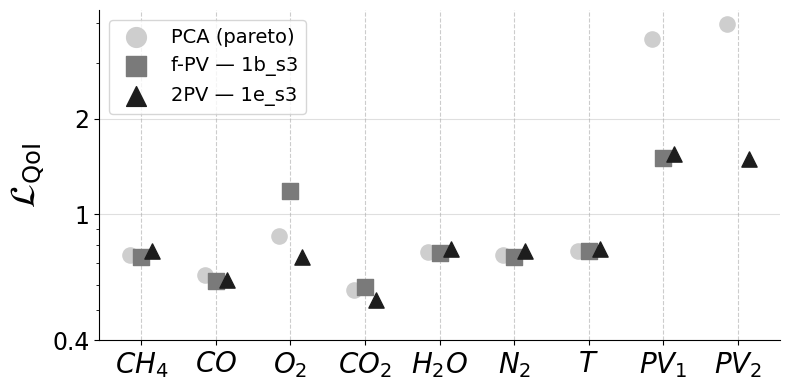

In [22]:
save = True
savePath = "C:/Users/Admin/Documents/PhD-ULB/Figures/2026-PV-optimization-for-practical-ROM/2022-Malik/Visualizations/costs/"
saveName = "Overview QoI costs - PCA - f-PV 1b_s3 - 2PVs 1e_s3"

species = ["CH4", "CO", "O2", "CO2", "H2O", "N2", "T", "PV1", "PV2"]

idx_species = range(6)
idx_T = 6
idx_PC1_PV1 = 7
idx_PC2_PV2 = 8

def smart_format_y_ticks(x, pos):
    if abs(x) < 1e-8:
        return "0"
    elif abs(x - round(x)) < 1e-8:
        return str(int(x))
    else:
        return f"{x:.1f}"


def format_species_name_for_latex(name: str) -> str:
    return re.sub(r'(\d+)', r'_{\1}', name)


greys = cm.get_cmap('Greys')


# ---- single axis ----
fig, ax = plt.subplots(figsize=(8, 4))


x_positions = np.arange(len(species))
width = 0.15


labels = [
    "PCA (pareto)",
    "f-PV \u2014 1b_s3",
    "2PV \u2014 1e_s3"
]

markers = ['o', 's', '^']
colors = [
    greys(0.3),
    greys(0.6),
    greys(0.9)
]


# plot costs for each species
for i, sp in enumerate(species):

    x0 = x_positions[i]

    offsets = np.array([-1, 0, 1]) * width

    # cost arrays must have length = number of species + QoIs
    # here we extract only the species part
    if i <= 5:  # species
        y_values = [
            costsPCA[i],
            costsf_PV_1b[i],
            costs2PV_1f[i]
        ]

    elif i == 6:  # temperature
        y_values = [
            costsPCA[i],
            costsf_PV_1b[i],
            costs2PV_1f[i]
        ]

    elif i == 7:  # PC1/PV1
        y_values = [
            costsPCA[7],
            costsf_PV_1b[7],
            costs2PV_1f[7]
        ]

    elif i == 8:  # PC2/PV2
        y_values = [
            costsPCA[8],
            None,
            costs2PV_1f[8]
        ]

    for dx, y, m, c, l in zip(
        offsets,
        y_values,
        markers,
        colors,
        labels
    ):
        ax.scatter(
            x0 + dx,
            y,
            marker=m,
            color=c,
            s=120,
            zorder=3,
            label=l
        )


# avoid duplicate legend entries
handles, legend_labels = ax.get_legend_handles_labels()
by_label = dict(zip(legend_labels, handles))
ax.legend(
    by_label.values(),
    by_label.keys(),
    fontsize=14,
    markerscale=1.3,
    loc="best"
)


# x labels
species_labels = [
    format_species_name_for_latex(sp)
    for sp in species
]

ax.set_xticks(x_positions)
ax.set_xticklabels(
    [f"${lbl}$" for lbl in species_labels],
    fontsize=20
)


# log scale
ax.set_yscale("log")

# adjust depending on your costs range
ax.set_yticks([4e-1, 1, 2])

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(smart_format_y_ticks)
)

ax.tick_params(
    axis='y',
    labelsize=17
)

ax.set_ylabel(
    r"$\mathcal{L}_{\mathrm{QoI}}$",
    fontsize=25
)


# grid
for x in x_positions:
    ax.axvline(
        x=x,
        color='gray',
        linestyle='--',
        linewidth=0.8,
        alpha=0.4,
        zorder=0
    )


ax.grid(
    axis='y',
    alpha=0.4
)


# clean frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()


if save:
    fig.savefig(
        savePath + saveName + ".png",
        dpi=300,
        bbox_inches="tight"
    )
    fig.savefig(
        savePath + saveName + ".pdf",
        bbox_inches="tight"
    )

plt.show()